In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("market_sales_prediction.csv")

print(df.shape)
df.head()

(8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# 1. Item_Weight → Median
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())

# 2. Item_Visibility → 0 fix
df['Item_Visibility'] = df['Item_Visibility'].replace(0, df['Item_Visibility'].mean())

# 3. Outlet_Size → Mode
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# 4. Clean Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF':'Low Fat', 'low fat':'Low Fat', 'reg':'Regular'
})

In [ ]:
# Outlet Age
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

# Visibility Ratio
visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
df['Item_Visibility_MeanRatio'] = df['Item_Visibility'] / visibility_mean

# Item Type Combined
df['Item_Type_Combined'] = df['Item_Identifier'].apply(lambda x: x[:2])
df['Item_Type_Combined'] = df['Item_Type_Combined'].map({
    'FD':'Food', 'NC':'Non-Consumable', 'DR':'Drinks'
})

# Non-consumable fat fix
df.loc[df['Item_Type_Combined']=='Non-Consumable','Item_Fat_Content']='Non-Edible'

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Item_Fat_Content','Outlet_Location_Type','Outlet_Size',
        'Outlet_Type','Item_Type_Combined']

for col in cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Item_Fat_Content','Outlet_Location_Type','Outlet_Size',
        'Outlet_Type','Item_Type_Combined']

for col in cols:
    df[col] = le.fit_transform(df[col]).astype(str)

In [70]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Item_Type'] = le.fit_transform(df['Item_Type'])

In [71]:
print(df.dtypes)
print("Total NaN:", df.isnull().sum().sum())

Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                      int64
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
Outlet_Age                     int64
Item_Visibility_MeanRatio    float64
Item_Type_Combined               str
dtype: object
Total NaN: 0


In [72]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Visibility_MeanRatio,Item_Type_Combined
0,FDA15,9.30,0,0.016047,4,249.8092,OUT049,1999,1,0,1,3735.1380,27,0.922960,1
1,DRC01,5.92,2,0.019278,14,48.2692,OUT018,2009,1,2,2,443.4228,17,1.003057,0
2,FDN15,17.50,0,0.016760,10,141.6180,OUT049,1999,1,0,1,2097.2700,27,0.831990,1
3,FDX07,19.20,2,0.066132,6,182.0950,OUT010,1998,1,2,0,732.3800,28,1.772137,1
4,NCD19,8.93,1,0.066132,9,53.8614,OUT013,1987,0,2,1,994.7052,39,1.607168,2


In [73]:
X = df.drop(['Item_Outlet_Sales','Item_Identifier','Outlet_Identifier'], axis=1)
y = df['Item_Outlet_Sales']

In [78]:
X = pd.get_dummies(X, drop_first=True)

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svr = SVR()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
svr.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [81]:
print(X.dtypes)

Item_Weight                  float64
Item_Visibility              float64
Item_Type                      int64
Item_MRP                     float64
Outlet_Establishment_Year      int64
Outlet_Age                     int64
Item_Visibility_MeanRatio    float64
Item_Fat_Content_1              bool
Item_Fat_Content_2              bool
Outlet_Size_1                   bool
Outlet_Size_2                   bool
Outlet_Location_Type_1          bool
Outlet_Location_Type_2          bool
Outlet_Type_1                   bool
Outlet_Type_2                   bool
Outlet_Type_3                   bool
Item_Type_Combined_1            bool
Item_Type_Combined_2            bool
dtype: object


In [82]:
from sklearn.metrics import r2_score

for name, model in [('LR',lr), ('RF',rf), ('SVR',svr)]:
    pred = model.predict(X_test)
    print(name, "R2:", r2_score(y_test, pred))

LR R2: 0.5813969734635168
RF R2: 0.5655910445146796
SVR R2: -0.026369184739002627


KNeighborsRegressor


In [83]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)
pred_knn = knn.predict(X_test_scaled)
print("KNN R2 Score:", r2_score(y_test, pred_knn))


KNN R2 Score: 0.5004660149962915


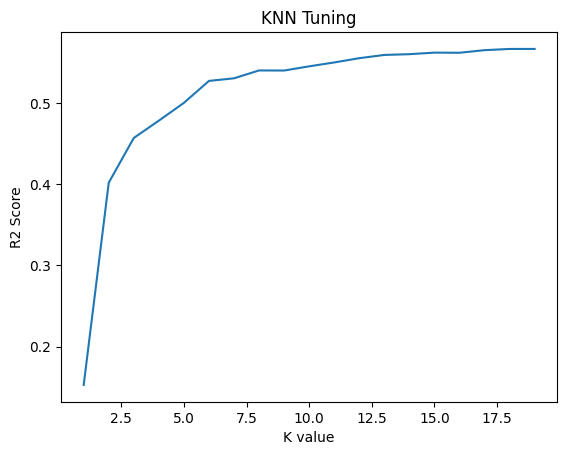

In [84]:
import matplotlib.pyplot as plt

scores = []

for k in range(1, 20):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    scores.append(r2_score(y_test, pred))

plt.plot(range(1,20), scores)
plt.xlabel("K value")
plt.ylabel("R2 Score")
plt.title("KNN Tuning")
plt.show()